# Single-cell MyoScore: UMAP & Age Correlation

Two independent atlases:
- **HLMA** (Lai et al. Nature 2024): 292K cells, 15–99 yr
- **Sanger SKM** (Eraslan et al.): 183K cells, 15–75 yr

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Illustrator-compatible fonts
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
mpl.rcParams['font.size'] = 8

# Project colors
COLORS = ["#50327b", "#46508b", "#31848f", "#72c95e", "#f4e030"]
COLOR_YOUNG = "#72c95e"
COLOR_OLD = "#50327b"
COLOR_HLMA = "#e07b39"
COLOR_SANGER = "#2878b5"

OUT = "/home/hua/Research/Myopathy Spectrum Multiomics/MyoScore/figures"
DATA = "/home/hua/Research/Myopathy Spectrum Multiomics/MyoScore/data"

## 1. Load Data

In [2]:
# Load HLMA
adata_hlma = sc.read_h5ad(
    f"{DATA}/Multimodal cell atlas of the ageing human skeletal muscle All_CellType_scsn_RNA.h5ad",
    backed='r'
)
print(f"HLMA: {adata_hlma.shape[0]} cells, {adata_hlma.obs['Annotation'].nunique()} cell types")
print(f"  Age: {adata_hlma.obs['age'].min():.0f}–{adata_hlma.obs['age'].max():.0f} yr")
print(f"  UMAP: {adata_hlma.obsm['X_umap'].shape}")

HLMA: 292423 cells, 15 cell types
  Age: 15–99 yr
  UMAP: (292423, 2)


In [3]:
# Load Sanger
adata_sanger = sc.read_h5ad(
    "/home/hua/Research/Myopathy Spectrum Multiomics/single_cell_data/SKM_human_pp_cells2nuclei.h5ad",
    backed='r'
)
print(f"Sanger: {adata_sanger.shape[0]} cells, {adata_sanger.obs['annotation_level0'].nunique()} cell types")
print(f"  Age groups: {sorted(adata_sanger.obs['Age_group'].unique())}")
print(f"  UMAP: {adata_sanger.obsm['X_umap'].shape}")

Sanger: 183161 cells, 36 cell types
  Age groups: ['15-20', '20-25', '25-30', '35-40', '50-55', '55-60', '60-65', '70-75']
  UMAP: (183161, 2)


In [ ]:
# Load cached MyoScore obs (csv.gz for cross-env compatibility)
obs_hlma = pd.read_csv(f"{DATA}/sc_myoscore_obs_cache.csv.gz", index_col=0)
obs_sanger = pd.read_csv(f"{DATA}/sc_myoscore_sanger_obs_cache.csv.gz", index_col=0)

# Add UMAP coordinates to obs
obs_hlma['UMAP1'] = adata_hlma.obsm['X_umap'][:, 0]
obs_hlma['UMAP2'] = adata_hlma.obsm['X_umap'][:, 1]
obs_sanger['UMAP1'] = adata_sanger.obsm['X_umap'][:, 0]
obs_sanger['UMAP2'] = adata_sanger.obsm['X_umap'][:, 1]

print(f"HLMA obs: {obs_hlma.shape}, Sanger obs: {obs_sanger.shape}")

## 2. UMAP: Cell Type + MyoScore

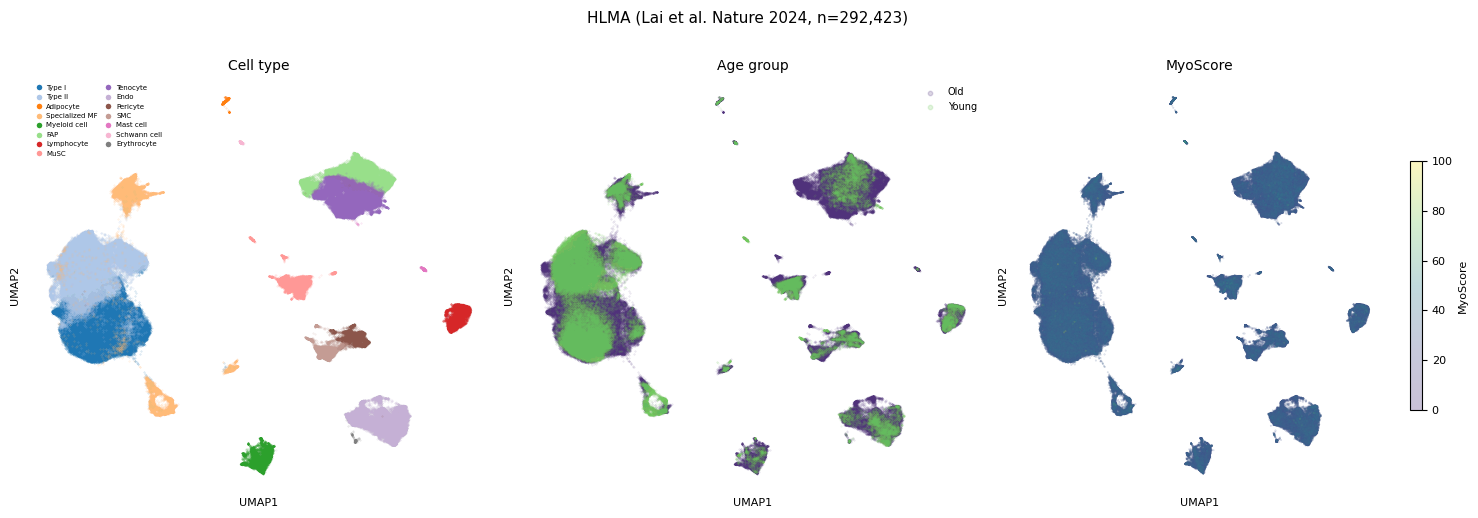

In [11]:
# ---- HLMA UMAP ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Cell type
ax = axes[0]
ct_colors = dict(zip(obs_hlma['Annotation'].unique(),
                      plt.cm.tab20.colors[:obs_hlma['Annotation'].nunique()]))
for ct, color in ct_colors.items():
    mask = obs_hlma['Annotation'] == ct
    ax.scatter(obs_hlma.loc[mask, 'UMAP1'], obs_hlma.loc[mask, 'UMAP2'],
              c=[color], s=0.1, alpha=0.3, rasterized=True)
ax.set_title('Cell type', fontsize=10)
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.legend([plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=5)
           for c in ct_colors.values()],
          ct_colors.keys(), fontsize=5, loc='best', ncol=2, frameon=False,
          markerscale=1, handletextpad=0.1, columnspacing=0.5)

# Panel 2: Age (young vs old)
ax = axes[1]
# Plot old first, young on top
for pop, color, label in [('old_pop', COLOR_OLD, 'Old'), ('young_pop', COLOR_YOUNG, 'Young')]:
    mask = obs_hlma['age_pop'] == pop
    ax.scatter(obs_hlma.loc[mask, 'UMAP1'], obs_hlma.loc[mask, 'UMAP2'],
              c=color, s=0.1, alpha=0.2, rasterized=True, label=label)
ax.set_title('Age group', fontsize=10)
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.legend(fontsize=7, markerscale=10, frameon=False)

# Panel 3: MyoScore
ax = axes[2]
cmap_ms = LinearSegmentedColormap.from_list('myoscore', ['#50327b', '#46508b', '#31848f', '#72c95e', '#f4e030'])
order = obs_hlma['MyoScore'].argsort()  # plot low scores first
sc_plot = ax.scatter(obs_hlma['UMAP1'].values[order], obs_hlma['UMAP2'].values[order],
                     c=obs_hlma['MyoScore'].values[order], cmap=cmap_ms,
                     s=0.1, alpha=0.3, rasterized=True)
ax.set_title('MyoScore', fontsize=10)
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
plt.colorbar(sc_plot, ax=ax, shrink=0.6, label='MyoScore')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

fig.suptitle('HLMA (Lai et al. Nature 2024, n=292,423)', fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(f"{OUT}/sc_UMAP_HLMA.pdf", dpi=300, bbox_inches='tight')
fig.savefig(f"{OUT}/sc_UMAP_HLMA.png", dpi=300, bbox_inches='tight')
plt.show()

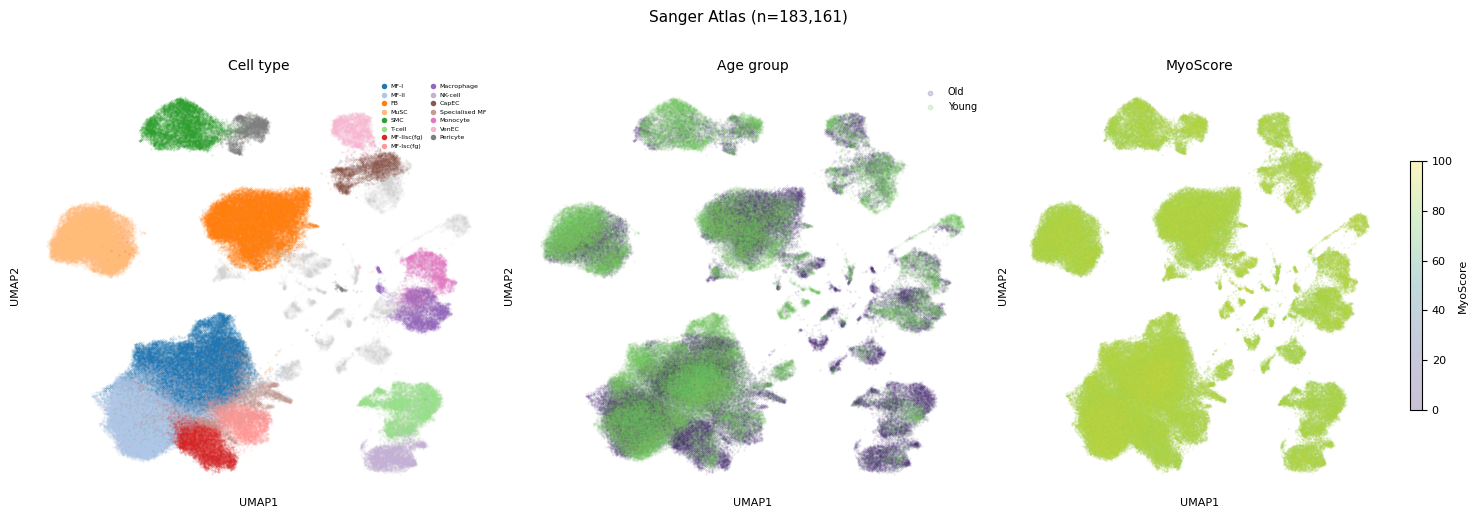

In [10]:
# ---- Sanger UMAP ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Cell type (annotation_level0)
ax = axes[0]
top_cts = obs_sanger['annotation_level0'].value_counts().head(15).index.tolist()
ct_colors_s = dict(zip(top_cts, plt.cm.tab20.colors[:len(top_cts)]))
for ct, color in ct_colors_s.items():
    mask = obs_sanger['annotation_level0'] == ct
    ax.scatter(obs_sanger.loc[mask, 'UMAP1'], obs_sanger.loc[mask, 'UMAP2'],
              c=[color], s=0.1, alpha=0.3, rasterized=True)
# Other cell types in gray
mask_other = ~obs_sanger['annotation_level0'].isin(top_cts)
if mask_other.sum() > 0:
    ax.scatter(obs_sanger.loc[mask_other, 'UMAP1'], obs_sanger.loc[mask_other, 'UMAP2'],
              c='lightgray', s=0.1, alpha=0.1, rasterized=True)
ax.set_title('Cell type', fontsize=10)
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.legend([plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=5)
           for c in ct_colors_s.values()],
          ct_colors_s.keys(), fontsize=4.5, loc='best', ncol=2, frameon=False,
          markerscale=1, handletextpad=0.1, columnspacing=0.5)

# Panel 2: Age (young vs old)
ax = axes[1]
for pop, color, label in [('old', COLOR_OLD, 'Old'), ('young', COLOR_YOUNG, 'Young')]:
    mask = obs_sanger['Age_bin'] == pop
    ax.scatter(obs_sanger.loc[mask, 'UMAP1'], obs_sanger.loc[mask, 'UMAP2'],
              c=color, s=0.1, alpha=0.2, rasterized=True, label=label)
ax.set_title('Age group', fontsize=10)
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.legend(fontsize=7, markerscale=10, frameon=False)

# Panel 3: MyoScore
ax = axes[2]
order = obs_sanger['MyoScore'].argsort()
sc_plot = ax.scatter(obs_sanger['UMAP1'].values[order], obs_sanger['UMAP2'].values[order],
                     c=obs_sanger['MyoScore'].values[order], cmap=cmap_ms,
                     s=0.1, alpha=0.3, rasterized=True)
ax.set_title('MyoScore', fontsize=10)
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
plt.colorbar(sc_plot, ax=ax, shrink=0.6, label='MyoScore')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

fig.suptitle('Sanger Atlas (n=183,161)', fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(f"{OUT}/sc_UMAP_Sanger.pdf", dpi=300, bbox_inches='tight')
fig.savefig(f"{OUT}/sc_UMAP_Sanger.png", dpi=300, bbox_inches='tight')
plt.show()

## 3. Panel d: MyoScore vs Age (Pseudobulk all cell types, both atlases)

In [7]:
# Prepare ALL-CELL pseudobulk donor scores (analogous to bulk RNA-seq)

# HLMA: all cell types
donor_hlma = obs_hlma.groupby('sample').agg({
    'MyoScore': 'mean', 'MyoScore_Youth': 'mean',
    'age': 'first', 'age_pop': 'first'
}).reset_index()
donor_hlma['atlas'] = 'HLMA'

# Sanger: all cell types
age_map = {'15-20': 17.5, '20-25': 22.5, '25-30': 27.5, '35-40': 37.5,
           '50-55': 52.5, '55-60': 57.5, '60-65': 62.5, '70-75': 72.5}
obs_sanger_tmp = obs_sanger.copy()
obs_sanger_tmp['age_numeric'] = obs_sanger_tmp['Age_group'].map(age_map)

donor_sanger = obs_sanger_tmp.groupby('DonorID').agg({
    'MyoScore': 'mean', 'MyoScore_Youth': 'mean',
    'age_numeric': 'first', 'Age_bin': 'first'
}).reset_index()
donor_sanger.rename(columns={'age_numeric': 'age', 'Age_bin': 'age_pop'}, inplace=True)
donor_sanger['age_pop'] = donor_sanger['age_pop'].map({'young': 'young_pop', 'old': 'old_pop'})
donor_sanger['atlas'] = 'Sanger'

donors = pd.concat([
    donor_hlma[['MyoScore', 'MyoScore_Youth', 'age', 'age_pop', 'atlas']],
    donor_sanger[['MyoScore', 'MyoScore_Youth', 'age', 'age_pop', 'atlas']]
])

# Z-score within each atlas to remove batch effect
for col in ['MyoScore', 'MyoScore_Youth']:
    for atlas in ['HLMA', 'Sanger']:
        mask = donors['atlas'] == atlas
        vals = donors.loc[mask, col]
        donors.loc[mask, col + '_z'] = (vals - vals.mean()) / vals.std()

print(f"Total donors: {len(donors)} ({(donors['atlas']=='HLMA').sum()} HLMA, {(donors['atlas']=='Sanger').sum()} Sanger)")
print(f"All cells: HLMA={len(obs_hlma)}, Sanger={len(obs_sanger)}")

Total donors: 40 (23 HLMA, 17 Sanger)
All cells: HLMA=292423, Sanger=183161


HLMA: ρ=-0.337, P=0.1157
Sanger: ρ=-0.378, P=0.1350
Combined: ρ=-0.387, P=0.0136


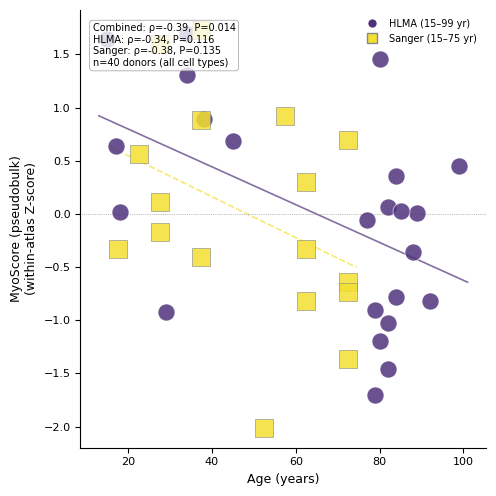

In [15]:
# ---- Panel d: Scatter plot (all cell types pseudobulk) ----
fig, ax = plt.subplots(figsize=(5, 5))

# Project colors for the two atlases
C_HLMA = "#50327b"   # purple
C_SANGER = "#f4e030"  # yellow

# Plot each donor
for _, row in donors.iterrows():
    color = C_HLMA if row['atlas'] == 'HLMA' else C_SANGER
    marker = 'o' if row['atlas'] == 'HLMA' else 's'
    ec = 'white' if row['atlas'] == 'HLMA' else '#888888'
    ax.scatter(row['age'], row['MyoScore_z'], c=color, s=150, alpha=0.85,
              edgecolors=ec, linewidth=0.5, marker=marker, zorder=3)

# Per-atlas regression lines
for atlas, color, ls in [('HLMA', C_HLMA, '-'), ('Sanger', C_SANGER, '--')]:
    sub = donors[donors['atlas'] == atlas]
    r_a, p_a = stats.spearmanr(sub['age'], sub['MyoScore_z'])
    slope_a, intercept_a = np.polyfit(sub['age'], sub['MyoScore_z'], 1)
    x_a = np.linspace(sub['age'].min() - 2, sub['age'].max() + 2, 50)
    ax.plot(x_a, slope_a * x_a + intercept_a, color=color, linewidth=1.2,
           linestyle=ls, alpha=0.7)
    print(f"{atlas}: ρ={r_a:.3f}, P={p_a:.4f}")

# Combined stats
r, p = stats.spearmanr(donors['age'], donors['MyoScore_z'])
print(f"Combined: ρ={r:.3f}, P={p:.4f}")

# Per-atlas raw correlation
r_h, p_h = stats.spearmanr(donor_hlma['age'], donor_hlma['MyoScore'])
r_s, p_s = stats.spearmanr(donor_sanger['age'], donor_sanger['MyoScore'])

ax.axhline(y=0, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('Age (years)', fontsize=9)
ax.set_ylabel('MyoScore (pseudobulk)\n(within-atlas Z-score)', fontsize=9)

stats_text = (f'Combined: ρ={r:.2f}, P={p:.3f}\n'
              f'HLMA: ρ={r_h:.2f}, P={p_h:.3f}\n'
              f'Sanger: ρ={r_s:.2f}, P={p_s:.3f}\n'
              f'n={len(donors)} donors (all cell types)')
ax.text(0.03, 0.97, stats_text, transform=ax.transAxes, fontsize=7, va='top',
       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8,
                 edgecolor='gray', linewidth=0.5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
leg = [Line2D([0],[0], marker='o', color='w', markerfacecolor=C_HLMA,
              markersize=7, markeredgecolor='white', linestyle='', label='HLMA (15–99 yr)'),
       Line2D([0],[0], marker='s', color='w', markerfacecolor=C_SANGER,
              markersize=7, markeredgecolor='#888888', linestyle='', label='Sanger (15–75 yr)')]
ax.legend(handles=leg, loc='upper right', fontsize=7, frameon=False)

plt.tight_layout()
fig.savefig(f"{OUT}/sc_MyoScore_vs_age_pseudobulk.pdf", dpi=300, bbox_inches='tight')
fig.savefig(f"{OUT}/sc_MyoScore_vs_age_pseudobulk.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Quick stats summary
print("=== Summary ===")
print(f"HLMA all cells: {len(obs_hlma)} cells, {len(donor_hlma)} donors")
print(f"Sanger all cells: {len(obs_sanger)} cells, {len(donor_sanger)} donors")
print(f"\nHLMA MyoScore vs age (pseudobulk): ρ={r_h:.3f}, P={p_h:.4f}")
print(f"Sanger MyoScore vs age (pseudobulk): ρ={r_s:.3f}, P={p_s:.4f}")
print(f"Combined: ρ={r:.3f}, P={p:.4f}")

=== Summary ===
HLMA all cells: 292423 cells, 23 donors
Sanger all cells: 183161 cells, 17 donors

HLMA MyoScore vs age (pseudobulk): ρ=-0.337, P=0.1157
Sanger MyoScore vs age (pseudobulk): ρ=-0.378, P=0.1350
Combined: ρ=-0.387, P=0.0136
